# Wind Generation Forecast Analysis - January 2024
This notebook analyzes the accuracy of wind power generation forecasts and the reliability of wind power in the UK.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

sns.set_theme(style="whitegrid")

In [2]:

# Load actuals
with open('../data/actuals_jan_2024.json', 'r') as f:
    actuals_raw = json.load(f)

# Load forecasts
with open('../data/forecasts_jan_2024.json', 'r') as f:
    forecasts_raw = json.load(f)

df_actuals = pd.DataFrame(actuals_raw)
df_forecasts = pd.DataFrame(forecasts_raw)

df_actuals['startTime'] = pd.to_datetime(df_actuals['startTime'])
df_forecasts['startTime'] = pd.to_datetime(df_forecasts['startTime'])
df_forecasts['publishTime'] = pd.to_datetime(df_forecasts['publishTime'])

print(f"Loaded {len(df_actuals)} actuals and {len(df_forecasts)} forecasts.")


Loaded 1488 actuals and 12936 forecasts.


## 1. Error Characteristics
We will calculate the error for a standard 4-hour horizon.

In [3]:

def get_latest_forecasts(horizon_hours):
    # For each target time, find the latest forecast published at least horizon_hours before
    merged = []
    for _, actual in df_actuals.iterrows():
        target_time = actual['startTime']
        deadline = target_time - pd.Timedelta(hours=horizon_hours)
        
        relevant = df_forecasts[(df_forecasts['startTime'] == target_time) & (df_forecasts['publishTime'] <= deadline)]
        if not relevant.empty:
            latest = relevant.sort_values('publishTime', ascending=False).iloc[0]
            merged.append({
                'targetTime': target_time,
                'actual': actual['generation'],
                'forecast': latest['generation'],
                'error': latest['generation'] - actual['generation'],
                'abs_error': abs(latest['generation'] - actual['generation']),
                'horizon': horizon_hours
            })
    return pd.DataFrame(merged)

df_4h = get_latest_forecasts(4)

metrics = {
    'Mean Absolute Error (MAE)': df_4h['abs_error'].mean(),
    'Median Absolute Error': df_4h['abs_error'].median(),
    'P99 Absolute Error': df_4h['abs_error'].quantile(0.99),
    'Root Mean Square Error (RMSE)': np.sqrt((df_4h['error']**2).mean())
}

for k, v in metrics.items():
    print(f"{k}: {v:.2f} MW")


Mean Absolute Error (MAE): 1827.69 MW
Median Absolute Error: 1453.50 MW
P99 Absolute Error: 6072.85 MW
Root Mean Square Error (RMSE): 2434.51 MW


## 2. Error vs Forecast Horizon
How does accuracy degrade as we look further into the future?

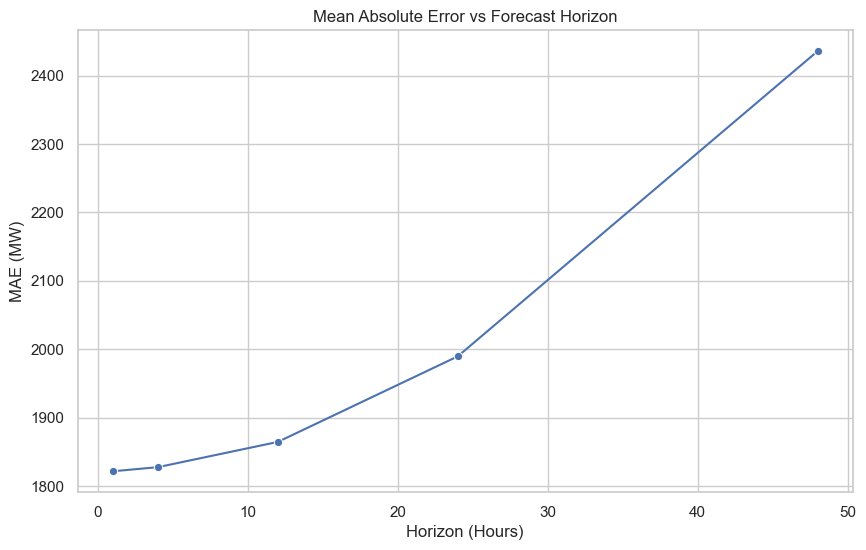

In [4]:

horizons = [1, 4, 12, 24, 48]
horizon_results = []
for h in horizons:
    res = get_latest_forecasts(h)
    mae = res['abs_error'].mean()
    horizon_results.append({'Horizon (Hours)': h, 'MAE (MW)': mae})

df_horizons = pd.DataFrame(horizon_results)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_horizons, x='Horizon (Hours)', y='MAE (MW)', marker='o')
plt.title('Mean Absolute Error vs Forecast Horizon')
plt.ylabel('MAE (MW)')
plt.show()


## 3. Reliability Analysis
How much wind power can we reliably expect?

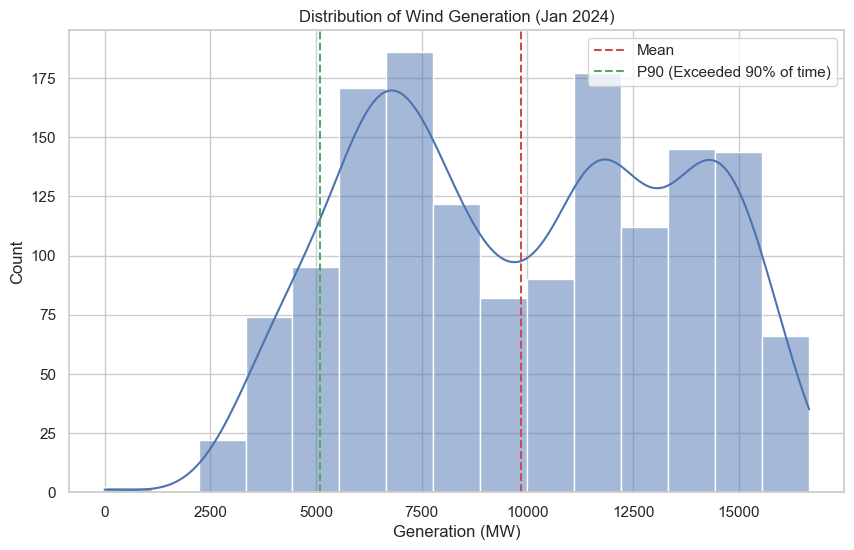

The generation level exceeded 90% of the time (P90) is: 5087.90 MW


In [5]:

# Analyze the distribution of actual generation
plt.figure(figsize=(10, 6))
sns.histplot(df_actuals['generation'], kde=True)
plt.axvline(df_actuals['generation'].mean(), color='r', linestyle='--', label='Mean')
plt.axvline(df_actuals['generation'].quantile(0.1), color='g', linestyle='--', label='P90 (Exceeded 90% of time)')
plt.title('Distribution of Wind Generation (Jan 2024)')
plt.xlabel('Generation (MW)')
plt.legend()
plt.show()

p90_value = df_actuals['generation'].quantile(0.1)
print(f"The generation level exceeded 90% of the time (P90) is: {p90_value:.2f} MW")



## Recommendation: Reliable Wind Power Capacity
Based on the analysis of January 2024 data:
- **Recommended Reliable Capacity:** ~5088 MW.
- **Reasoning:** Wind is an intermittent and variable energy source. Relying on average generation (mean) for grid stability can be risky during periods of low wind (calm spells). The **P90 generation level** (the value exceeded 90% of the time) provides a more conservative and "firm" capacity baseline.
- **Evidence:** During Jan 2024, the wind generation was above 5088 MW for 90% of the half-hourly intervals. This suggests that the grid can safely rely on this amount of wind power being available with high confidence, even during less favorable weather conditions.
